In [1]:
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt

## __Histograma de distancia SP a NearestLink__

In [5]:
snapped_bus_stops = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Transporte Publico/SP (snapped including service)/meters/busStops_snapped_M.shp')
snapped_bus_stops

,id,mobiliario,iluminaci,señal_ver,señal_hor,banqueta,vegetació,ruta_1,ruta_2,ruta_3,...,NearestNod,NearestN_1,NearestEdg,SnapDist_m,NearestLin,RelPosOnLi,FromNodeNo,ToNodeNo,NearestL_1,geometry
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 13A Solidaridad,Troncal 13B Solidaridad,T13A-C02,...,1771858665,3304,"(1771858665, 8778745267, 0)",8.207127,9238,0.0,3304,30379,secondary,POINT (680976.456 2272736.641)
1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,Troncal 19 Periferico,C19,C46-V1,...,1700484749,2340,"(1677124239, 1700484749, 0)",8.441228,4352,1.0,1495,2340,primary,POINT (681483.254 2280845.501)
2,3.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,8407044728,24811,"(8407044724, 8407044728, 0)",6.982640,65242,1.0,24808,24811,residential,POINT (700561.553 2281164.022)
3,4.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,1746083332,2947,"(1746083332, 8778413347, 0)",10.527186,8267,0.0,2947,30220,secondary,POINT (700707.084 2281320.114)
4,5.0,0.0,1.0,0.0,0.0,1.0,0.0,T21 Zapotlanejo,T21-C01,R1-Tepetates,...,1746083335,2948,"(1746090115, 1746083335, 0)",4.600218,8384,1.0,2997,2948,secondary,POINT (700907.289 2281378.235)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,5987144952,16245,"(6322033098, 6322033110, 0)",8.663037,49413,0.0,18239,18245,primary,POINT (699396.25 2280168.108)
12514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,8414023283,25555,"(6322039422, 8414023283, 0)",1.691836,49451,0.0,18255,25555,primary,POINT (699836.994 2280555.417)
12515,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,1746083377,2959,"(1746083353, 1746083377, 0)",2.215223,8288,1.0,2957,2959,secondary,POINT (701461.661 2281478.528)
12516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None,...,1746293814,3072,"(1746195132, 1746293814, 0)",5.281715,8511,1.0,3047,3072,tertiary,POINT (701108.581 2281835.306)


In [12]:
snapped_bus_stops['SnapDist_m'].describe()

count    12518.000000
mean         6.272968
std          6.407991
min          0.025854
25%          4.522057
50%          5.832953
75%          7.474535
max        351.077823
Name: SnapDist_m, dtype: float64

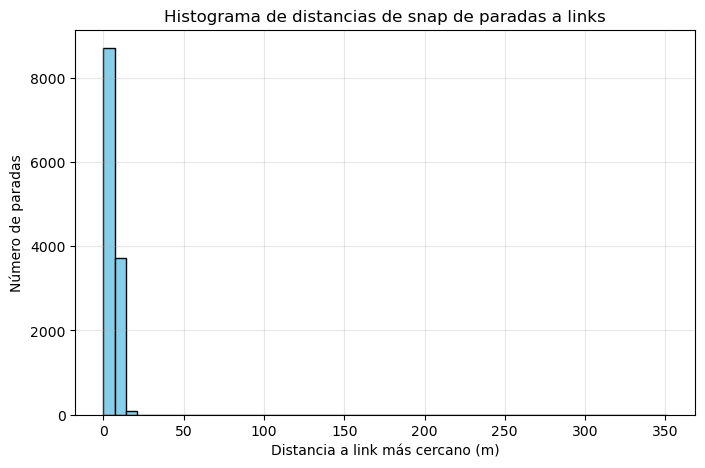

In [16]:
import matplotlib.pyplot as plt

# Histograma de distancias de snap (en metros)
plt.figure(figsize=(8, 5))
plt.hist(snapped_bus_stops["SnapDist_m"], bins=50, color='skyblue', edgecolor='black',)
plt.xlabel("Distancia a link más cercano (m)")
plt.ylabel("Número de paradas")
plt.title("Histograma de distancias de snap de paradas a links")
plt.grid(True, alpha=0.3)
plt.show()

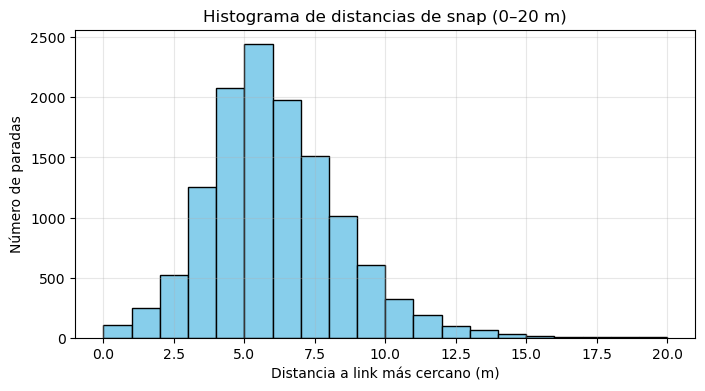

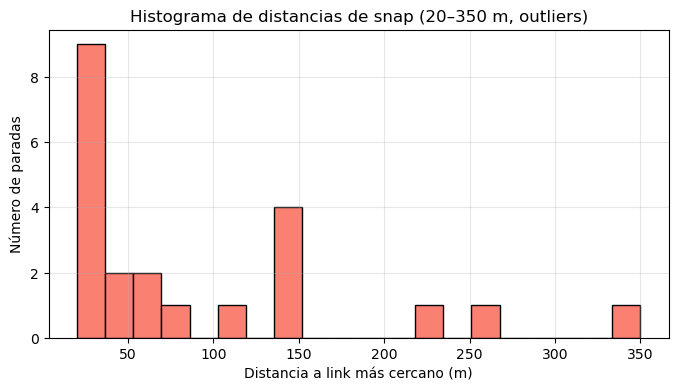

In [20]:
import matplotlib.pyplot as plt

# Histograma para distancias pequeñas (0–20 m)
plt.figure(figsize=(8, 4))
plt.hist(snapped_bus_stops["SnapDist_m"], bins=20, color='skyblue', edgecolor='black', range=(0, 20))
plt.xlabel("Distancia a link más cercano (m)")
plt.ylabel("Número de paradas")
plt.title("Histograma de distancias de snap (0–20 m)")
plt.grid(True, alpha=0.3)
plt.show()

# Histograma para outliers (20–350 m)
plt.figure(figsize=(8, 4))
plt.hist(snapped_bus_stops["SnapDist_m"], bins=20, color='salmon', edgecolor='black', range=(20, 350))
plt.xlabel("Distancia a link más cercano (m)")
plt.ylabel("Número de paradas")
plt.title("Histograma de distancias de snap (20–350 m, outliers)")
plt.grid(True, alpha=0.3)
plt.show()

## __Remove outliers from Bus Stops to get the STATS__

In [23]:
bus_stops_noOutliers = snapped_bus_stops[snapped_bus_stops["SnapDist_m"] <= 20]
distance_mean = bus_stops_noOutliers["SnapDist_m"].mean()
distance_std = bus_stops_noOutliers["SnapDist_m"].std()
distance_var = bus_stops_noOutliers["SnapDist_m"].var()

print(f"Distancia media (sin outliers): {distance_mean:.2f} m")
print(f"Desviación estándar (sin outliers): {distance_std:.2f} m")
print(f"Varianza (sin outliers): {distance_var:.2f} m")

Distancia media (sin outliers): 6.10 m
Desviación estándar (sin outliers): 2.40 m
Varianza (sin outliers): 5.78 m


## __Get a threshold__

In [38]:
# con 3 veces sigma habia varios que se quedaban fuera porque verdaderamente su nearest link estaba a ej. 14.58
threshold = distance_mean + 4 * distance_std
threshold

np.float64(15.71291059364513)

## __For every Bus Stop, look for links within that Threshold__

In [26]:
# Nodes & Edges de G_snap (en metros)
nodes_Gsnap = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Base Snap/Nodes/meters/nodes_snap_m.shp')
edges_Gsnap = gpd.read_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Red Base Snap/Edges/meters/edges_snap_m.shp')

In [31]:
edges_Gsnap['highway'].value_counts()

highway
residential                         268213
service                              70245
tertiary                             27855
unclassified                         14092
secondary                            10088
primary                               7614
trunk                                 1414
primary_link                           777
tertiary_link                          735
trunk_link                             554
secondary_link                         508
motorway_link                          487
motorway                               371
['residential', 'living_street']       195
['residential', 'track']               132
['residential', 'service']              74
['service', 'track']                    50
['unclassified', 'track']               38
['residential', 'tertiary']             37
['residential', 'unclassified']         24
['unclassified', 'service']              8
['living_street', 'service']             8
['tertiary', 'trunk_link']               7
['u

In [42]:
import ast

def parse_highway(val):
    if isinstance(val, str) and val.startswith('['):
        try:
            return ast.literal_eval(val)
        except Exception:
            return val
    return val

edges_Gsnap['highway'] = edges_Gsnap['highway'].apply(parse_highway)

In [43]:
link_hierarchy = [
    'motorway', 'motorway_link',
    'trunk', 'trunk_link',
    'primary', 'primary_link',
    'secondary', 'secondary_link',
    'tertiary', 'tertiary_link',
    'unclassified',
    'residential',
    'service'
]
nearest_link_id = []
nearest_u = []
nearest_v = []

for stop in snapped_bus_stops.itertuples():
    bus_stop_buffer = stop.geometry.buffer(threshold) #13.3
    candidate_edges = edges_Gsnap[
        edges_Gsnap.geometry.intersects(bus_stop_buffer)
    ]
    
    selected_edge = None

    for highway_type in link_hierarchy:
        # Busca edges donde 'highway' sea igual o contenga hwy_type
        mask = candidate_edges['highway'].apply(
            lambda h: highway_type in h if isinstance(h, list) else highway_type == h
        )
        filtered_edges = candidate_edges[mask]
        if not filtered_edges.empty:
            selected_edge = filtered_edges.iloc[0]  # Selecciona el primer edge que cumpla la condición
            break

    if selected_edge is not None:
        nearest_link_id.append(selected_edge['osmid'])
        nearest_u.append(selected_edge['u'])
        nearest_v.append(selected_edge['v'])
    else:
        print(f"STOP {stop.id} sin match. Candidates:")
        for h in candidate_edges['highway']:
            print(f"  {h!r} (type: {type(h)})")
        nearest_link_id.append(None)
        nearest_u.append(None)
        nearest_v.append(None)

    #print(f"Parada ID: {stop.id}, # of candidate links: {len(candidate_edges)}")

snapped_bus_stops['NearestID'] = nearest_link_id
snapped_bus_stops['NearestU'] = nearest_u
snapped_bus_stops['NearestV'] = nearest_v


STOP 201.0 sin match. Candidates:
STOP 503.0 sin match. Candidates:
STOP 569.0 sin match. Candidates:
STOP 1403.0 sin match. Candidates:
STOP 1408.0 sin match. Candidates:
STOP 1411.0 sin match. Candidates:
STOP 1415.0 sin match. Candidates:
STOP 1425.0 sin match. Candidates:
STOP 1426.0 sin match. Candidates:
STOP 1582.0 sin match. Candidates:
STOP 1592.0 sin match. Candidates:
STOP 1600.0 sin match. Candidates:
STOP 1885.0 sin match. Candidates:
STOP 1998.0 sin match. Candidates:
STOP 2031.0 sin match. Candidates:
STOP 2033.0 sin match. Candidates:
STOP 2034.0 sin match. Candidates:
STOP 2197.0 sin match. Candidates:
STOP 2322.0 sin match. Candidates:
STOP 2323.0 sin match. Candidates:
STOP 2345.0 sin match. Candidates:
STOP 2346.0 sin match. Candidates:
STOP 2359.0 sin match. Candidates:
STOP 2361.0 sin match. Candidates:
STOP 2523.0 sin match. Candidates:
STOP 2542.0 sin match. Candidates:
STOP 2852.0 sin match. Candidates:
STOP 4602.0 sin match. Candidates:
STOP 5424.0 sin match. 

In [44]:
snapped_bus_stops.to_file(r'/Users/jeannettearjona/Library/CloudStorage/OneDrive-InstitutoTecnologicoydeEstudiosSuperioresdeMonterrey/Modelación Urbana - Red Vial Guadalajara/Insumos OSMNX/Transporte Publico/SP buffer_hierarchy/bus_stops_newAlg.shp')